Load Data

In [1]:
import torch
from data_split import load_data, concat_datasets
import numpy as np
import random

seed = 2025
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
rng = np.random.default_rng(seed)
torch.cuda.manual_seed_all(seed)

# choose from "PBMC", "Mouse-Cortex", "Mouse-Skin", "Human-Kidney", "Mouse-MOp", "BMMC", "CL", "UP_HK"
dataset_name = "mice_zebrafish"  # Human-Kidney Pancreas TMS PancreasHumanMouse Baron_Human_Mouse_Normalized ImmuneHumanMouse(2) Lung PurifiedPBMCDataset TS_Bone_Marrow TS_Skin Dorsal_Midbrain BGI PBMC_Time(2) PBMC_Sub Immune_PBMC_Human_Mouse Colorectal_Cancer Breast_Cancer RCC HGSOC BMMC_Kidney TMS_Fat_Limb TMS_marrow_spleen Mus_Kidney Giraddi_10x Han Hochane mice_zebrafish human_cortex_EaFet_Adol Zeisel_p20_p23 Zeisel_p20_p29 Retina_Human_Mouse Retina_Human_Mouse_v2 Retina_Human_Mouse_v3 Thymus_Cao_ALIGNED Liver_Human_Monkey TMS_Thymus mouse_heart_pancreas HNSCC_RNA CL_ATAC PBMC_ATAC_ASAP_seq BoneMarrowA_BoneMarrowB
setting = "setting1"  # setting1 setting3

omics = 1

omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, global_categories_id, global_categories_ood, mapping_ood, gene_name =load_data(dataset_name, setting, omics=1)
if omics1_test_id_loader is None:
    omics1_mixed_loader = omics1_test_ood_loader
else:
    omics1_mixed_loader = concat_datasets(omics1_test_id_loader, omics1_test_ood_loader)
    all_data_loader = concat_datasets(omics1_train_loader, omics1_mixed_loader)

print(f'ID: {global_categories_id}')
print(f'OOD: {global_categories_ood}')
print(f'Mapping OOD: {mapping_ood}')

print(len(global_categories_id))

[INFO] Split Train and Test Data by Batch: Train: ['heart']
[INFO] Split Train and Test Data by Batch: Test: ['pancreas']


Index(['B cell', 'T cell', 'cardiac muscle cell', 'dendritic cell',
       'endocardial cell', 'endothelial cell', 'fibroblast', 'fibrocyte',
       'granulocyte', 'macrophage', 'monocyte', 'natural killer cell',
       'pericyte'],
      dtype='object')
ID: Index(['B cell', 'T cell', 'cardiac muscle cell', 'dendritic cell',
       'endocardial cell', 'endothelial cell', 'fibroblast', 'fibrocyte',
       'granulocyte', 'macrophage', 'monocyte', 'natural killer cell',
       'pericyte'],
      dtype='object')
OOD: Index(['Schwann cell', 'exocrine cell', 'hepatic stellate cell',
       'pancreatic A cell', 'pancreatic D cell', 'pancreatic PP cell',
       'type B pancreatic cell'],
      dtype='object')
Mapping OOD: {13: 'pancreatic A cell', 14: 'type B pancreatic cell', 15: 'pancreatic D cell', 16: 'pancreatic PP cell', 17: 'hepatic stellate cell', 18: 'exocrine cell', 19: 'Schwann cell'}
13


Initialize the model

In [2]:
from scDiscovery_architecture import *
import torch.optim as optim

class_number = len(global_categories_id)

device = torch.device("cuda:3")

omics1_imput_size = omics1_train_loader.dataset[0][0].shape[0]

E_rna = Encoder(input_size=omics1_imput_size, z_dim=128).to(device)
Classifier = JointClassificationHead(z_dim=128, n_classes=class_number).to(device)

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

Contrastive-Reconstruction Representation Learning (CRRL)

In [3]:
from scDiscovery_architecture import Decoder
from algorithm_utils import train_decoder_classification_single_omics

D_rna = Decoder(input_size=omics1_imput_size, z_dim=128).to(device)

optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)

E_rna, D_rna, Classifier = train_decoder_classification_single_omics(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, num_epochs=5, device=device)


Epoch [1/5], CLS Loss: 0.3607, RNA Recon Loss: 0.1868, RNA KL Loss: 0.2137, Acc_train: 97.40, Acc_test: 97.74
Epoch [2/5], CLS Loss: 0.0749, RNA Recon Loss: 0.1326, RNA KL Loss: 0.1982, Acc_train: 97.83, Acc_test: 98.89
Epoch [3/5], CLS Loss: 0.0481, RNA Recon Loss: 0.1313, RNA KL Loss: 0.1979, Acc_train: 99.20, Acc_test: 99.09
Epoch [4/5], CLS Loss: 0.0304, RNA Recon Loss: 0.1304, RNA KL Loss: 0.1975, Acc_train: 99.66, Acc_test: 98.99
Epoch [5/5], CLS Loss: 0.0239, RNA Recon Loss: 0.1303, RNA KL Loss: 0.1987, Acc_train: 99.70, Acc_test: 98.08


Adaptive Decision Boundary Calibration (ADBC)

=================== Before Calibration ===================


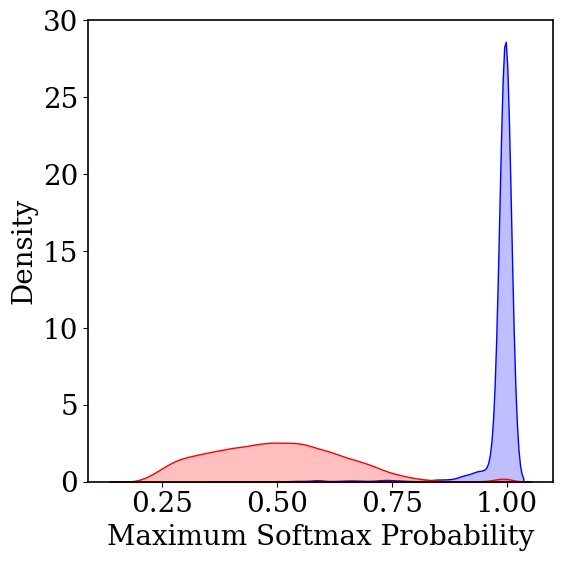

=================== After Calibration ===================


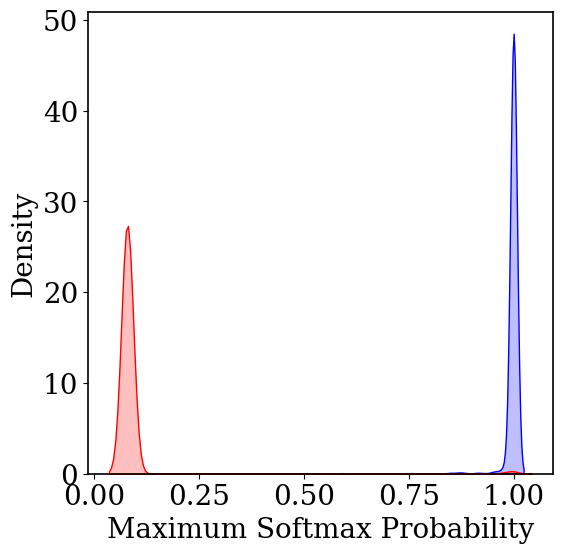

=================== ROC Curve ===================


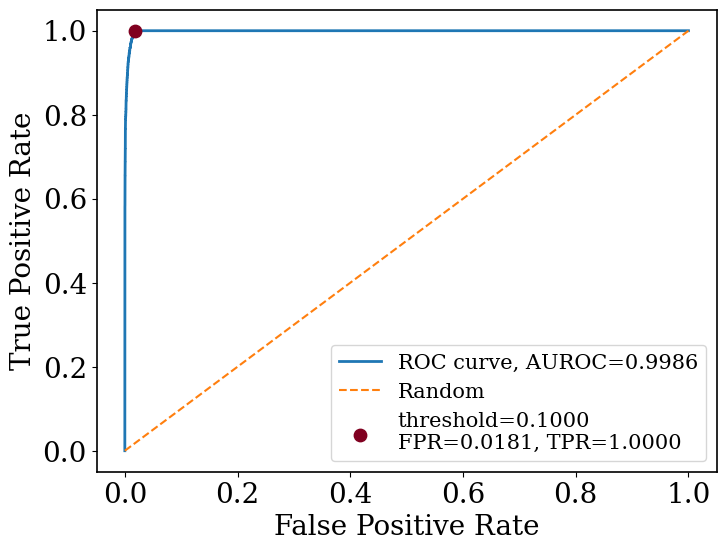

In [4]:
from calibration import adaptive_decision_boundary_calibration

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

threshold, filtered_omics1_ood_loader, filtered_omics1_id_loader = adaptive_decision_boundary_calibration(E_rna, Classifier, optimizer_E_rna, optimizer_fc, scheduler_E_rna, scheduler_fc, omics1_train_loader,omics1_test_id_loader, omics1_test_ood_loader, omics1_mixed_loader, class_number, device, dataset_name, setting, num_iters=1, num_epochs=5, recall_level=0.95)

Dynamic Novel Cell Type Expansion (DNCTE)

In [5]:
from dynamic_expansion import dynamic_novel_cell_type_expansion

adata = dynamic_novel_cell_type_expansion(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, scheduler_E_rna, scheduler_D_rna, filtered_omics1_ood_loader, omics1_train_loader, omics1_test_id_loader, omics1_mixed_loader, gene_name, class_number, num_epochs=5, device=device)

/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/dids/miniconda3/envs/scOOD/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/dids/hzh/github_project/scDiscovery/dynamic_expansion.py:742: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = torch.tensor(y)


Epoch [1/5], CLS Loss: 0.5398, RNA Recon Loss: 0.1218, RNA KL Loss: 0.2194, Acc_train: 87.93, Acc_test: 99.18
Epoch [2/5], CLS Loss: 0.1523, RNA Recon Loss: 0.1172, RNA KL Loss: 0.2251, Acc_train: 98.38, Acc_test: 97.93
Epoch [3/5], CLS Loss: 0.0512, RNA Recon Loss: 0.1167, RNA KL Loss: 0.2294, Acc_train: 99.40, Acc_test: 98.70
Epoch [4/5], CLS Loss: 0.0362, RNA Recon Loss: 0.1168, RNA KL Loss: 0.2283, Acc_train: 99.04, Acc_test: 97.79
Epoch [5/5], CLS Loss: 0.0313, RNA Recon Loss: 0.1167, RNA KL Loss: 0.2282, Acc_train: 99.75, Acc_test: 98.94


Evaluation

In [6]:
from metrics import evaluate_ncd_discovery_potential, calculate_discovery_asw
metrics = evaluate_ncd_discovery_potential(
    adata=adata,
    y_true='y_true_with_unknown',
    y_pred='y_pred_with_unknown',
    embed_key='X_scDiscovery',
    unknown_label='Unknown'
)

for k, v in metrics.items():
    print(f"{k}: {v}")

Multi-F1: 0.991493731863992
Multi-Accuracy: 0.9833856783919598
F1: 0.9914089638227569
Precision: 1.0
Recall: 0.9829642821141763


In [7]:
from metrics import evaluate_model_on_novel_clas

metrics_ood, _, recon_data_ood, y_true_ood, y_pred_ood, Emb_ood = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_ood_loader, device)  # train_rna_loader  omics1_test_ood_loader

print("Metrics:")
for k, v in metrics_ood.items():
        print(f"{k}: {v}")

Metrics:
ARI: 0.5252161630097719
AMI: 0.7540820872582937
NMI: 0.7542546515114597
HOM: 0.9046091954303145


Visualization

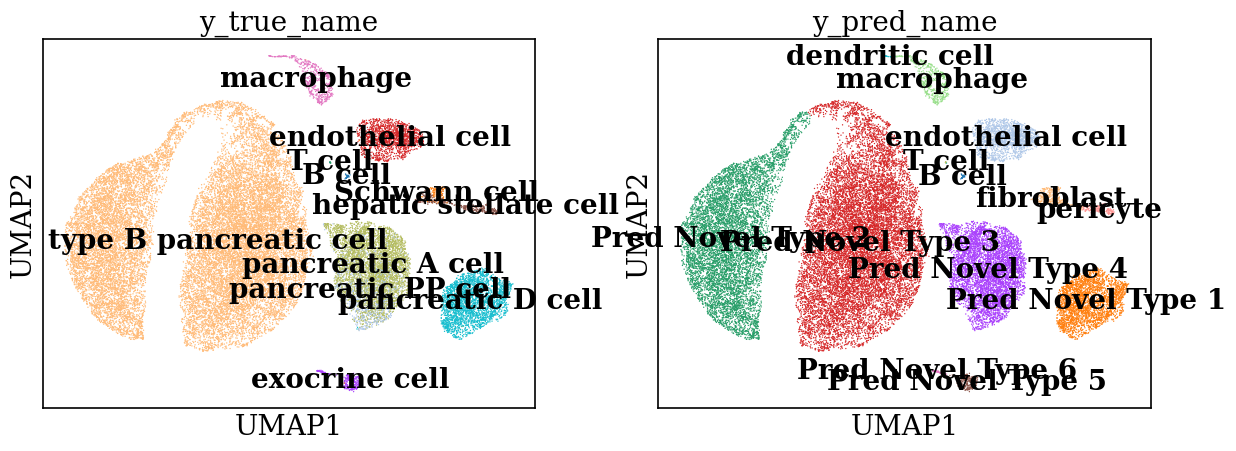

In [8]:
import scanpy as sc
from dynamic_expansion import cell_type_mapping

adata = cell_type_mapping(adata, global_categories_id, mapping_ood)

sc.pp.neighbors(adata, use_rep='X_scDiscovery', metric="cosine")
sc.tl.umap(adata)

sc.pl.umap(adata, color=['y_true_name', 'y_pred_name'], legend_loc='on data', save=f"_scDiscovery_umap_label_{dataset_name}_{setting}.png")